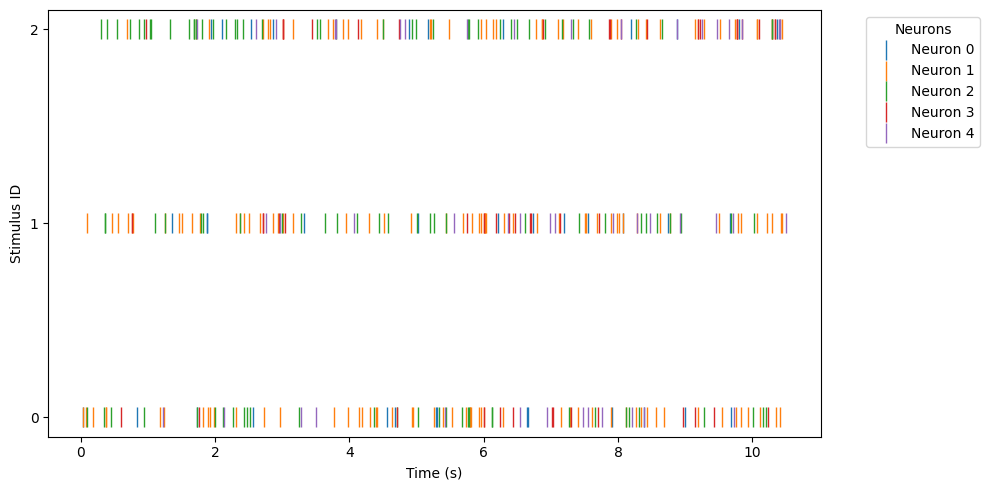

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import ast
from mozaik.storage.datastore import PickledDataStore
from parameters import ParameterSet
from mozaik.storage.queries import param_filter_query

# 1. Load Data
# Using a dataset string known from compare_stimulus_A.ipynb
ds = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": "SelfSustainedPushPull_test:VA_null35_____", "store_stimuli": False}),
    replace=False
)
dsv = param_filter_query(ds, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
segs = dsv.get_segments()

# 2. Extract Data
# We want to plot 10 stimuli (segments) and 5 neurons
# Select the first 10 segments
segments_to_plot = segs[0::2]

# Find available neurons and select 5 of them
all_uids = list(set([st.annotations.get('source_id', st.name) for st in segs[0].spiketrains]))
all_uids.sort()
selected_uids = all_uids[:5]
colors = ['C0', 'C1', 'C2', 'C3', 'C4']

# 3. Plot Raster Plot
plt.figure(figsize=(10, 5))

for stim_id, seg in enumerate(segments_to_plot):
    t_start = seg.t_start.rescale('s').magnitude
    
    for i, uid in enumerate(selected_uids):
        # find the spiketrain for this uid
        for st in seg.spiketrains:
            if st.annotations.get('source_id', st.name) == uid:
                # Align spikes to 0 for the segment
                spikes = st.rescale('s').magnitude - t_start
                
                # Plot the spikes
                if len(spikes) > 0:
                    plt.plot(spikes, [stim_id] * len(spikes), '|', color=colors[i], markersize=15, 
                             label=f'Neuron {i}' if stim_id == 0 else "")

plt.xlabel('Time (s)')
plt.ylabel('Stimulus ID')
plt.yticks(range(len(segments_to_plot)))

# To avoid duplicate labels in the legend, we deduplicate handles
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Neurons", loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [18]:
# 4. Calculate Firing Rates
firing_rates = {uid: [] for uid in selected_uids}

for seg in segments_to_plot:
    t_start = seg.t_start.rescale('s').magnitude
    t_stop = seg.t_stop.rescale('s').magnitude
    duration = t_stop - t_start
    
    for uid in selected_uids:
        for st in seg.spiketrains:
            if st.annotations.get('source_id', st.name) == uid:
                spike_count = len(st)
                firing_rates[uid].append(spike_count / duration)

mean_firing_rates = {uid: np.mean(rates) for uid, rates in firing_rates.items()}

print("Mean Firing Rates (Hz) across presented segments:")
for i, uid in enumerate(selected_uids):
    print(f"Neuron {i} (ID: {uid}): {mean_firing_rates[uid]:.2f} Hz")

Mean Firing Rates (Hz) across presented segments:
Neuron 0 (ID: 61286): 1.21 Hz
Neuron 1 (ID: 61287): 4.92 Hz
Neuron 2 (ID: 61288): 3.17 Hz
Neuron 3 (ID: 61289): 1.49 Hz
Neuron 4 (ID: 61290): 1.46 Hz
